# Data Preprocessing: Genre Story Dataset

This notebook handles:
1. Loading raw data
2. Text cleaning and normalization
3. Length filtering and truncation
4. Train/val/test splitting
5. Exporting processed datasets

All heavy functions are imported from `src/preprocessing.py` for reusability.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

# Add src directory to path so we can import our functions
sys.path.append('../src')

# Import our preprocessing functions
from preprocessing import (
    clean_text,
    calculate_word_count,
    truncate_text,
    filter_by_length,
    preprocess_stories,
    stratified_split,
    analyze_genre_distribution,
    get_preprocessing_stats,
    save_splits
)

# Styling
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Imports successful")

✓ Imports successful


## 1. Load Raw Data

In [12]:
# Load dataset
data_path = Path("../data/1k_stories_100_genre.csv")
df = pd.read_csv(data_path)

print(f"Loaded {len(df)} stories")
print(f"Columns: {df.columns.tolist()}")
df.head()

Loaded 1000 stories
Columns: ['id', 'title', 'story', 'genre']


,id,title,story,genre
0,457580,The Chronicles of the Cosmic Rift,"In the year 2250, Earth had made significant s...",Science Fiction
1,297904,Eldoria's Enchanted Whispers,"In a land far away, where the sun shone bright...",Fantasy
2,620436,Echoes of Whispered Shadows,"Once upon a time, in a small, tranquil town ca...",Mystery
3,634687,Emerald Amulet Chronicles Revealed,"Once upon a time in the 16th century, a small ...",Historical Adventure
4,513427,The Shadows of St. Augustine,In the sun-drenched coastal city of St. August...,Thriller


## 2. Analyze Raw Data Distribution

Word count statistics:
count    1000.000000
mean      985.861000
std       430.611272
min        83.000000
25%       804.000000
50%       978.500000
75%      1163.500000
max      3093.000000
Name: word_count, dtype: float64


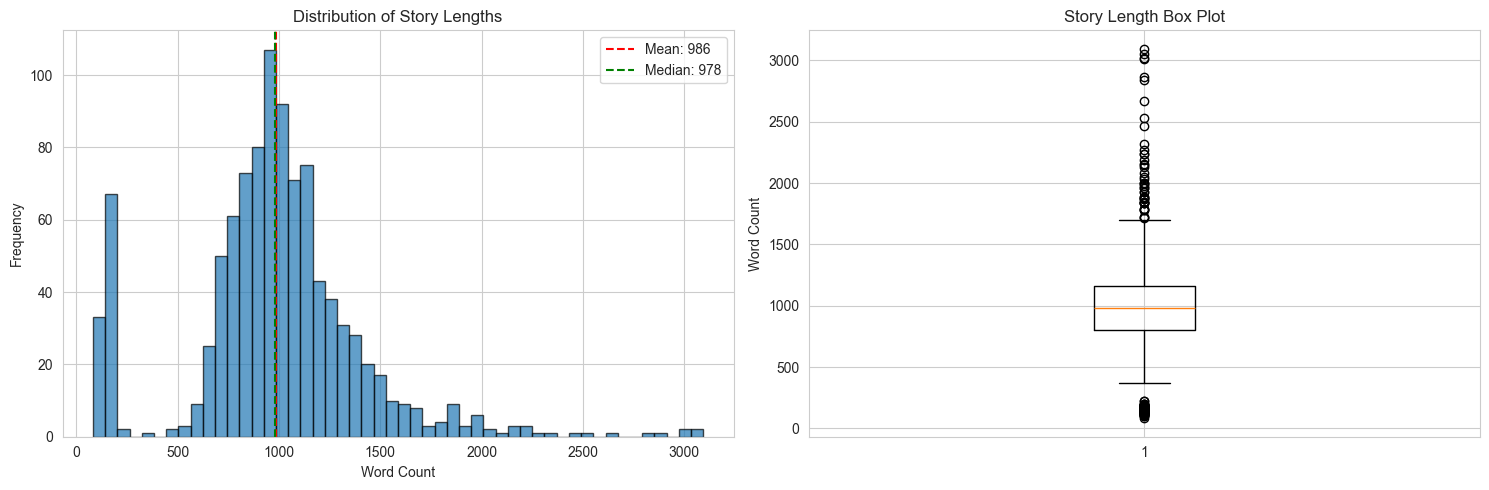

In [13]:
# Calculate word counts for raw data
df['word_count'] = df['story'].apply(calculate_word_count)

# Basic statistics
print("Word count statistics:")
print(df['word_count'].describe())

# Visualize distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['word_count'], bins=50, edgecolor='black', alpha=0.7)
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
axes[0].axvline(df['word_count'].median(), color='green', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Story Lengths')
axes[0].legend()

# Box plot
axes[1].boxplot(df['word_count'], vert=True)
axes[1].set_ylabel('Word Count')
axes[1].set_title('Story Length Box Plot')

plt.tight_layout()
plt.show()

## 3. Experiment with Different Length Limits

Let's see how different max_words values affect our dataset:


Impact of different max_words values:
 max_words  kept_intact  kept_intact_pct  truncated  truncated_pct
       500          105             10.5        895           89.5
       800          246             24.6        754           75.4
      1000          530             53.0        470           47.0
      1200          781             78.1        219           21.9


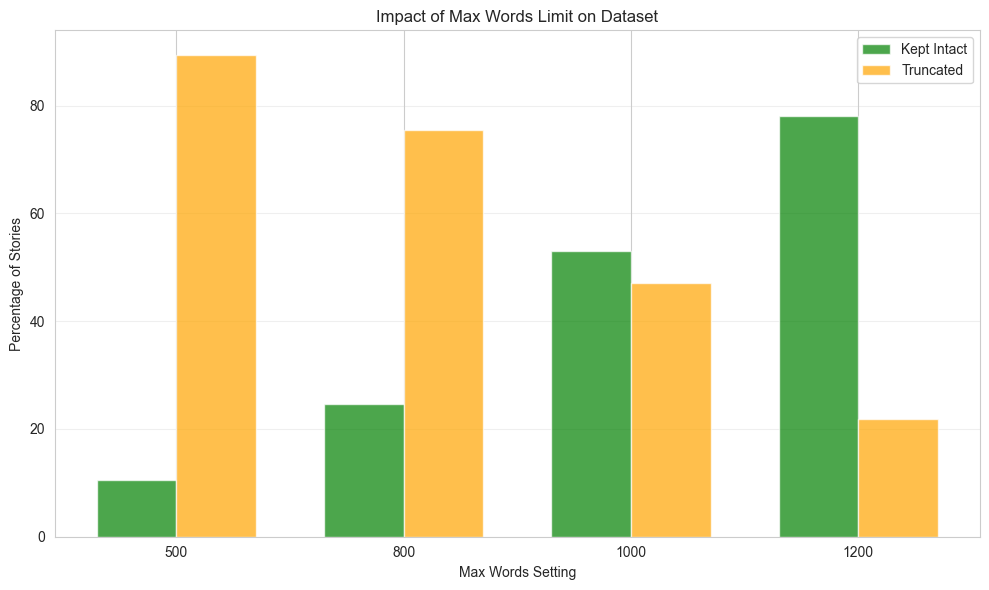

In [14]:
# Test different max_words values
max_words_options = [500, 800, 1000, 1200]

results = []
for max_words in max_words_options:
    kept_intact = (df['word_count'] <= max_words).sum()
    truncated = (df['word_count'] > max_words).sum()
    
    results.append({
        'max_words': max_words,
        'kept_intact': kept_intact,
        'kept_intact_pct': kept_intact / len(df) * 100,
        'truncated': truncated,
        'truncated_pct': truncated / len(df) * 100
    })

results_df = pd.DataFrame(results)
print("\nImpact of different max_words values:")
print(results_df.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
x = range(len(max_words_options))
width = 0.35

ax.bar([i - width/2 for i in x], results_df['kept_intact_pct'], width, label='Kept Intact', color='green', alpha=0.7)
ax.bar([i + width/2 for i in x], results_df['truncated_pct'], width, label='Truncated', color='orange', alpha=0.7)

ax.set_xlabel('Max Words Setting')
ax.set_ylabel('Percentage of Stories')
ax.set_title('Impact of Max Words Limit on Dataset')
ax.set_xticks(x)
ax.set_xticklabels(max_words_options)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Choose Preprocessing Parameters

Based on the analysis above, choose your parameters:

In [19]:
# PARAMETERS - Adjust these based on your analysis
MAX_WORDS = 1000      # Maximum words per story (will truncate longer ones)
MIN_WORDS = 50       # Minimum words per story (will filter out shorter ones)
CLEAN_TEXT = True    # Apply text cleaning

print(f"Chosen parameters:")
print(f"  MAX_WORDS: {MAX_WORDS}")
print(f"  MIN_WORDS: {MIN_WORDS}")
print(f"  CLEAN_TEXT: {CLEAN_TEXT}")

Chosen parameters:
  MAX_WORDS: 1000
  MIN_WORDS: 50
  CLEAN_TEXT: True


## 5. Apply Preprocessing Pipeline

In [20]:
# Apply full preprocessing
df_processed = preprocess_stories(
    df,
    max_words=MAX_WORDS,
    min_words=MIN_WORDS,
    clean=CLEAN_TEXT
)

print("\n" + "="*50)
print("Preprocessing complete!")
print("="*50)

Original dataset size: 1000 stories
Cleaning text...
Filtering stories with < 50 words...
After filtering: 1000 stories
Truncating stories to max 1000 words...
Stories truncated: 470 (47.0%)
Stories kept intact: 530 (53.0%)

Preprocessing complete!


## 6. Analyze Processed Data


Processed Dataset Statistics:
  total_stories: 1000.00
  unique_genres: 99.00
  word_count_mean: 845.55
  word_count_median: 978.50
  word_count_std: 256.01
  word_count_min: 83.00
  word_count_max: 1000.00


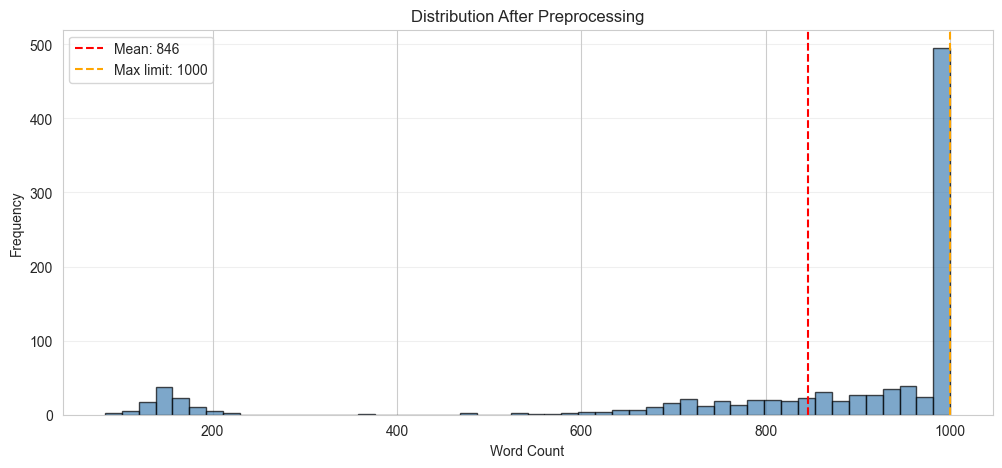

In [21]:
# Get statistics
stats = get_preprocessing_stats(df_processed)

print("\nProcessed Dataset Statistics:")
for key, value in stats.items():
    print(f"  {key}: {value:.2f}")

# Visualize processed distribution
plt.figure(figsize=(12, 5))
plt.hist(df_processed['word_count'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
plt.axvline(df_processed['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df_processed["word_count"].mean():.0f}')
plt.axvline(MAX_WORDS, color='orange', linestyle='--', label=f'Max limit: {MAX_WORDS}')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.title('Distribution After Preprocessing')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 7. Analyze Genre Distribution


Genre Distribution:
Total unique genres: 99

Top 10 genres:
                  genre  count  percentage
0  Historical Adventure     20         2.0
1       Science Fiction     10         1.0
2               Fantasy     10         1.0
3               Mystery     10         1.0
4              Thriller     10         1.0
5    Historical Fiction     10         1.0
6             Adventure     10         1.0
7                Horror     10         1.0
8                Comedy     10         1.0
9                 Crime     10         1.0

Bottom 10 genres:
                 genre  count  percentage
89  Apocalyptic Comedy     10         1.0
90     Virtual Reality     10         1.0
91      Suburban Drama     10         1.0
92        Magical Girl     10         1.0
93          War Comedy     10         1.0
94   Space Exploration     10         1.0
95   Steampunk Fantasy     10         1.0
96         Noir Comedy     10         1.0
97   Social Commentary     10         1.0
98      Techno-Mystery     

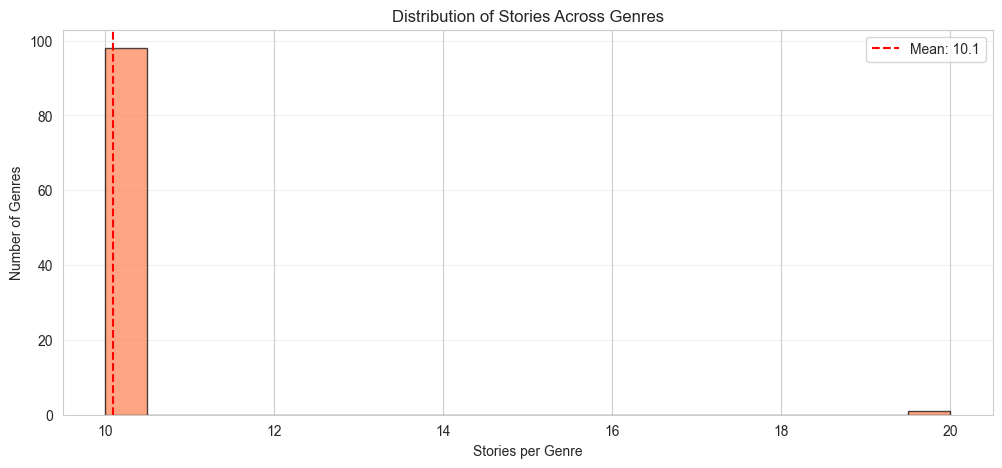

In [22]:
# Analyze genres
genre_stats = analyze_genre_distribution(df_processed)

print("\nGenre Distribution:")
print(f"Total unique genres: {len(genre_stats)}")
print(f"\nTop 10 genres:")
print(genre_stats.head(10))
print(f"\nBottom 10 genres:")
print(genre_stats.tail(10))

# Visualize
plt.figure(figsize=(12, 5))
genre_counts = df_processed['genre'].value_counts()
plt.hist(genre_counts.values, bins=20, edgecolor='black', alpha=0.7, color='coral')
plt.xlabel('Stories per Genre')
plt.ylabel('Number of Genres')
plt.title('Distribution of Stories Across Genres')
plt.axvline(genre_counts.mean(), color='red', linestyle='--', label=f'Mean: {genre_counts.mean():.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

## 8. Split into Train/Val/Test Sets

Using stratified splitting to maintain genre balance across splits.

In [23]:
# Split ratios
TRAIN_RATIO = 0.7
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_SEED = 42

# Perform stratified split
train_df, val_df, test_df = stratified_split(
    df_processed,
    stratify_column='genre',
    train_ratio=TRAIN_RATIO,
    val_ratio=VAL_RATIO,
    test_ratio=TEST_RATIO,
    random_state=RANDOM_SEED
)

Split sizes:
  Train: 699 (69.9%)
  Val:   150 (15.0%)
  Test:  151 (15.1%)


## 9. Verify Split Quality

Check that genre distribution is maintained across splits:

Genre distribution verification:

Train set - Top 5 genres:
genre
Historical Adventure    13
Space Opera              7
Psychological Horror     7
Evolutionary Fiction     7
Domestic Fiction         7
Name: count, dtype: int64

Val set - Top 5 genres:
genre
Historical Adventure    3
Existential Drama       2
Folklore                2
Gothic                  2
Fairy Tale              2
Name: count, dtype: int64

Test set - Top 5 genres:
genre
Historical Adventure    4
Spy Fiction             2
Historical Romance      2
Romantic Fantasy        2
Fantasy                 2
Name: count, dtype: int64


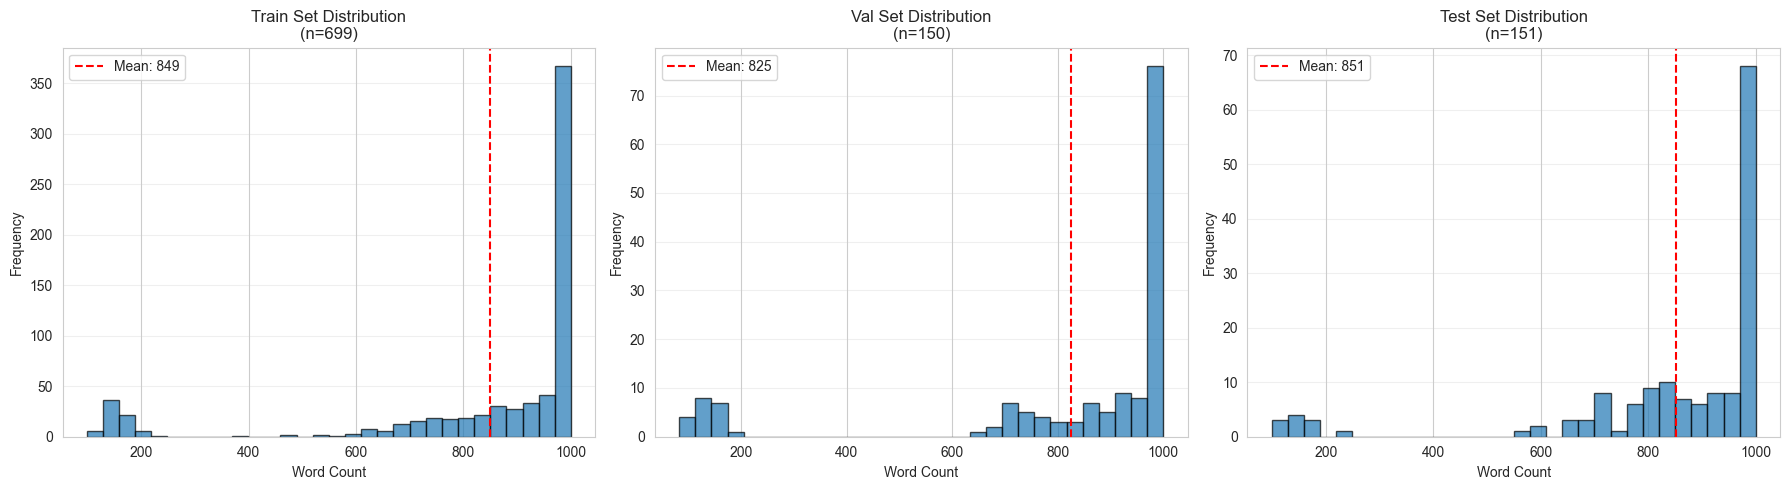

In [24]:
# Compare genre distributions
print("Genre distribution verification:")
print(f"\nTrain set - Top 5 genres:")
print(train_df['genre'].value_counts().head())

print(f"\nVal set - Top 5 genres:")
print(val_df['genre'].value_counts().head())

print(f"\nTest set - Top 5 genres:")
print(test_df['genre'].value_counts().head())

# Visualize word count distribution across splits
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, data) in zip(axes, [('Train', train_df), ('Val', val_df), ('Test', test_df)]):
    ax.hist(data['word_count'], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel('Word Count')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{name} Set Distribution\n(n={len(data)})')
    ax.axvline(data['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {data["word_count"].mean():.0f}')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Sample Examples from Each Split

In [25]:
# Look at a few examples
print("=" * 80)
print("SAMPLE FROM TRAINING SET")
print("=" * 80)

sample = train_df.sample(1).iloc[0]
print(f"Genre: {sample['genre']}")
print(f"Title: {sample['title']}")
print(f"Word count: {sample['word_count']}")
print(f"\nStory (first 500 chars):\n{sample['story'][:500]}...")

SAMPLE FROM TRAINING SET
Genre: Folklore
Title: The Enchanted Forest of Whispering Pines
Word count: 1000

Story (first 500 chars):
In the quiet village of Willowbrook, nestled within the valley of a majestic mountain range, there lay a dense forest that was known only to the villagers and the wandering travelers who occasionally passed through. The villagers called this forest the Enchanted Forest of Whispering Pines, for its trees had an uncanny ability to whisper secrets and share stories amongst themselves. The forest was home to a peculiar race of creatures, known as the Pine Whisperers, who were the guardians of the en...


## 11. Save Processed Datasets

In [26]:
# Save to CSV files
OUTPUT_DIR = "../data"

save_splits(
    train_df=train_df,
    val_df=val_df,
    test_df=test_df,
    output_dir=OUTPUT_DIR
)

print("\n✓ Preprocessing complete! Ready for tokenization and model training.")


Saved splits to ../data/
  train.csv: 699 stories
  val.csv:   150 stories
  test.csv:  151 stories

✓ Preprocessing complete! Ready for tokenization and model training.


## 12. Summary

Final preprocessing configuration:

In [27]:
summary = f"""
{'='*60}
PREPROCESSING SUMMARY
{'='*60}

Input:
  - Original dataset: {len(df)} stories
  - Genres: {df['genre'].nunique()}

Parameters:
  - Max words: {MAX_WORDS}
  - Min words: {MIN_WORDS}
  - Text cleaning: {CLEAN_TEXT}

Output:
  - Processed stories: {len(df_processed)}
  - Train set: {len(train_df)} ({len(train_df)/len(df_processed)*100:.1f}%)
  - Val set: {len(val_df)} ({len(val_df)/len(df_processed)*100:.1f}%)
  - Test set: {len(test_df)} ({len(test_df)/len(df_processed)*100:.1f}%)

Word Count Statistics (processed):
  - Mean: {df_processed['word_count'].mean():.1f}
  - Median: {df_processed['word_count'].median():.1f}
  - Std: {df_processed['word_count'].std():.1f}
  - Min: {df_processed['word_count'].min():.0f}
  - Max: {df_processed['word_count'].max():.0f}

Files saved to: {OUTPUT_DIR}/
  - train.csv
  - val.csv
  - test.csv

{'='*60}
"""

print(summary)


PREPROCESSING SUMMARY

Input:
  - Original dataset: 1000 stories
  - Genres: 99

Parameters:
  - Max words: 1000
  - Min words: 50
  - Text cleaning: True

Output:
  - Processed stories: 1000
  - Train set: 699 (69.9%)
  - Val set: 150 (15.0%)
  - Test set: 151 (15.1%)

Word Count Statistics (processed):
  - Mean: 845.6
  - Median: 978.5
  - Std: 256.0
  - Min: 83
  - Max: 1000

Files saved to: ../data/
  - train.csv
  - val.csv
  - test.csv


